<a href="https://colab.research.google.com/github/kamranshahid56-tech/multimodal-disease-prediction-from-chest-x-rays-radiology-reports/blob/main/multimodal_disease_prediction_from_chest_x_rays_%26_radiology_reports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# MULTIMODAL DISEASE PREDICTION FROM CHEST X-RAYS & RADIOLOGY REPORTS
# Late-Fusion Deep Learning Architecture (DenseNet-121 + ClinicalBERT)
# Dataset: MIMIC-CXR v2.0.0
# Target: 5 Classes — Cardiomegaly, Pleural Effusion, Edema, Pneumothorax, Pneumonia
# ============================================================


In [1]:
# Install all packages not available by default in Colab.
# - transformers: Hugging Face library for ClinicalBERT
# - torchvision: DenseNet-121 and image transforms
# - scikit-learn: metrics (AUROC, F1, confusion matrix)
# - opencv-python: CLAHE image enhancement
# - pandas / numpy: data manipulation
# - matplotlib / seaborn: plotting

!pip install -q transformers torchvision scikit-learn opencv-python-headless pandas numpy matplotlib seaborn tqdm

#CELL 2 — Download Datasets & Set Paths   

In [2]:
# Step 1: Install Kaggle API
!pip install -q kaggle

# Step 2: Upload your kaggle.json API key
# Get it from: kaggle.com → Profile → Settings → API → Create New Token
from google.colab import files
print("Upload your kaggle.json file when prompted...")
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("✔ Kaggle credentials set")

# Step 3: Download and unzip (~1 GB)
print("Downloading Indiana University CXR dataset...")
!kaggle datasets download -d raddar/chest-xrays-indiana-university \
    -p /content/indiana-cxr/ --unzip

# Step 4: Verify contents
print("\nFiles downloaded:")
!ls /content/indiana-cxr/
print("\nSample image files:")
!ls /content/indiana-cxr/images/images_normalized/ | head -5
print("\nTotal images:")
!ls /content/indiana-cxr/images/images_normalized/ | wc -l

# Step 5: Set paths used by all remaining cells
IMAGE_DIR  = '/content/indiana-cxr/images/images_normalized'
REPORT_CSV = '/content/indiana-cxr/indiana_reports.csv'
PROJ_CSV   = '/content/indiana-cxr/indiana_projections.csv'

print("\n✔ All paths set:")
print(f"  IMAGE_DIR  = {IMAGE_DIR}")
print(f"  REPORT_CSV = {REPORT_CSV}")
print(f"  PROJ_CSV   = {PROJ_CSV}")

Upload your kaggle.json file when prompted...


Saving kaggle (2).json to kaggle (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✔ Kaggle credentials set
Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 13.2G/13.2G [13:12<00:00, 17.8MB/s]


Files downloaded:
images	indiana_projections.csv  indiana_reports.csv

Sample image files:
1000_IM-0003-1001.dcm.png
1000_IM-0003-2001.dcm.png
1000_IM-0003-3001.dcm.png
1001_IM-0004-1001.dcm.png
1001_IM-0004-1002.dcm.png

Total images:
7470

✔ All paths set:
  IMAGE_DIR  = /content/indiana-cxr/images/images_normalized
  REPORT_CSV = /content/indiana-cxr/indiana_reports.csv
  PROJ_CSV   = /content/indiana-cxr/indiana_projections.csv


#CELL 3 — Imports & Global Config

In [3]:
import re
import random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [4]:
# ── Reproducibility seed ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {DEVICE}")

Running on: cuda


In [6]:
CLASSES = ['Cardiomegaly', 'Pleural Effusion', 'Edema', 'Pneumothorax', 'Pneumonia']
NUM_CLASSES = len(CLASSES)

In [7]:
# ── Training hyperparameters (from the paper) ─────────────────
BATCH_SIZE   = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS   = 25
MAX_TEXT_LEN = 256    # ClinicalBERT token limit used in the paper
DROPOUT_RATE = 0.3
FC_HIDDEN    = 512    # hidden units in the fusion head
IMAGE_SIZE   = 224    # DenseNet-121 input resolution

#CELL 4 — Data Loading & Label Parsing

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 4 — FIXED (correct column names from actual CSV)     ║
# ╚══════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load both CSVs
reports_df = pd.read_csv(REPORT_CSV)
proj_df    = pd.read_csv(PROJ_CSV)

# Keep only FRONTAL views
frontal_df = proj_df[proj_df['projection'].str.lower() == 'frontal'].copy()
print(f"Frontal images: {len(frontal_df)} out of {len(proj_df)} total")

# Merge frontal projections with reports on uid
df = pd.merge(frontal_df, reports_df, on='uid', how='inner')

# Drop duplicate uid rows — keep first frontal image per report
df = df.drop_duplicates(subset='uid').reset_index(drop=True)
print(f"Unique studies after dedup: {len(df)}")

# ── Convert MeSH tags → binary label columns ──────────────────
# FIXED: actual column is 'MeSH' not 'problems'
# MeSH contains tags like "Cardiomegaly/borderline;Pulmonary Artery/enlarged"
# Note: separated by semicolons, may have subtypes after "/" e.g. "Cardiomegaly/borderline"

LABEL_MAP = {
    'Cardiomegaly'    : ['cardiomegaly'],
    'Pleural Effusion': ['effusion', 'pleural effusion'],
    'Edema'           : ['edema', 'pulmonary edema'],
    'Pneumothorax'    : ['pneumothorax'],
    'Pneumonia'       : ['pneumonia', 'pneumonitis'],
}

for class_name, keywords in LABEL_MAP.items():
    df[class_name] = df['MeSH'].fillna('').str.lower().apply(
        lambda x: 1.0 if any(k in x for k in keywords) else 0.0
    )

# Check label counts before filtering
print("\nLabel counts BEFORE removing all-zero rows:")
print(df[CLASSES].sum())

# Remove rows where ALL 5 labels are 0
df = df[df[CLASSES].sum(axis=1) > 0].reset_index(drop=True)
print(f"\nRows with at least one positive label: {len(df)}")

# ── Train / Val / Test split 70 / 15 / 15 ─────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30,
                                     random_state=42, shuffle=True)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     random_state=42, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nSplit → Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nLabel prevalence in training set (% positive):")
print((train_df[CLASSES].mean() * 100).round(2))

Frontal images: 3818 out of 7466 total
Unique studies after dedup: 3689

Label counts BEFORE removing all-zero rows:
Cardiomegaly        319.0
Pleural Effusion    141.0
Edema                41.0
Pneumothorax         25.0
Pneumonia            36.0
dtype: float64

Rows with at least one positive label: 474

Split → Train: 331 | Val: 71 | Test: 72

Label prevalence in training set (% positive):
Cardiomegaly        66.16
Pleural Effusion    30.51
Edema                9.37
Pneumothorax         5.74
Pneumonia            6.95
dtype: float64


#CELL 5 — Report Text Preprocessing

In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 5 — Report Text Preprocessing  (REWRITTEN)          ║
# ╚══════════════════════════════════════════════════════════════╝

# Unlike MIMIC-CXR where reports are .txt files on disk,
# Indiana CXR reports are already loaded in the DataFrame as columns:
#   findings  → detailed radiologist observations
#   impression → summary / conclusion
#
# We concatenate findings + impression as the text input to ClinicalBERT
# (same sections extracted in the MIMIC-CXR version)

import re

def build_report_text(row) -> str:
    """
    Combine findings and impression columns into a single clean string.
    Handles NaN values and removes boilerplate/noise.
    """
    findings   = str(row['findings'])   if pd.notna(row['findings'])   else ''
    impression = str(row['impression']) if pd.notna(row['impression']) else ''

    # Remove NaN strings that pandas sometimes leaves
    findings   = '' if findings   in ('nan', 'NaN', 'None') else findings
    impression = '' if impression in ('nan', 'NaN', 'None') else impression

    # Clean whitespace
    findings   = re.sub(r'\s+', ' ', findings).strip()
    impression = re.sub(r'\s+', ' ', impression).strip()

    combined = ' '.join(filter(None, [findings, impression]))

    # Fallback: use indication if both are empty
    if not combined:
        indication = str(row.get('indication', ''))
        combined = re.sub(r'\s+', ' ', indication).strip()

    return combined if combined else 'no findings'


# Build a report cache dict keyed by uid (same pattern as before)
# This avoids reprocessing text during Dataset.__getitem__
print("Building report cache from DataFrame columns...")
report_cache = {}
for _, row in df.iterrows():
    report_cache[row['uid']] = build_report_text(row)

# Verify quality
empty_count = sum(1 for v in report_cache.values() if v == 'no findings')
print(f"✔ Reports cached: {len(report_cache)} | Empty/fallback: {empty_count}")
print("\nSample report text:")
sample_uid = list(report_cache.keys())[0]
print(report_cache[sample_uid][:300])


Building report cache from DataFrame columns...
✔ Reports cached: 474 | Empty/fallback: 0

Sample report text:
Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX. No acute pulmonary findings.


#CELL 6 — Image Preprocessing & Augmentation

In [11]:
# The paper applies:
#   1. Resize to 224×224
#   2. Convert to 3-channel (grayscale CXR replicated across RGB)
#   3. CLAHE (Contrast Limited Adaptive Histogram Equalization)
#      to enhance low-contrast lung detail
#   4. ImageNet normalisation (mean & std)
#   5. Light augmentation during training only:
#      ±10° rotation, horizontal flip, small translations

# ImageNet channel statistics (used because DenseNet-121 is pretrained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# CLAHE parameters — clip limit and tile grid size
CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def apply_clahe(img_array: np.ndarray) -> np.ndarray:
    """Apply CLAHE to a grayscale numpy image and return 3-channel array."""
    # Ensure uint8
    if img_array.dtype != np.uint8:
        img_array = (img_array * 255).astype(np.uint8)
    enhanced = CLAHE.apply(img_array)
    # Replicate single channel to 3 channels (RGB expected by DenseNet-121)
    return np.stack([enhanced, enhanced, enhanced], axis=-1)


# torchvision transforms for TRAINING (with augmentation)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=10),           # ±10° rotation
    transforms.RandomHorizontalFlip(),               # horizontal flip
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # small translation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# torchvision transforms for VALIDATION / TEST (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

#CELL 7 — Dataset Class

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 7 — Dataset Class  (REWRITTEN FOR INDIANA CXR)       ║
# ╚══════════════════════════════════════════════════════════════╝

# Key differences from MIMIC-CXR version:
#   1. Images are PNG not JPG
#   2. Image filename comes from 'filename_x' column (after merge)
#      format: "1000_IM-0003-1001" — no extension stored in CSV
#   3. Report text comes from report_cache[uid] not from disk files
#   4. Row identifier is 'uid' not 'subject_id'+'study_id'

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class IndianaXRayDataset(Dataset):
    def __init__(self, dataframe, tokenizer, report_cache,
                 image_dir, transform=None):
        """
        Args:
            dataframe    : train_df / val_df / test_df subset
            tokenizer    : ClinicalBERT tokenizer
            report_cache : dict mapping uid → cleaned report text
            image_dir    : path to images/images_normalized/
            transform    : torchvision transform pipeline
        """
        self.df           = dataframe.reset_index(drop=True)
        self.tokenizer    = tokenizer
        self.report_cache = report_cache
        self.image_dir    = image_dir
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def _get_image_path(self, row):
        """
        Indiana CXR image path:
          images/images_normalized/{filename}.png
        The filename column contains the stem without extension.
        After the merge, the image filename is in 'filename_x'
        (pandas adds _x/_y suffix when both CSVs have 'filename').
        """
        # Use filename_x (from projections) — the actual image file stem
        fname = str(row.get('filename_x', row.get('filename', '')))
        return os.path.join(self.image_dir, f'{fname}.png')

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Load and preprocess image ──────────────────────────
        img_path = self._get_image_path(row)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            # Graceful fallback for missing files
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
        img = apply_clahe(img)       # CLAHE enhancement + 3-channel
        if self.transform:
            img = self.transform(img)

        # ── Load report text ───────────────────────────────────
        text = self.report_cache.get(row['uid'], 'no findings')
        encoding = self.tokenizer(
            text,
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # ── Multi-label binary target vector ───────────────────
        labels = torch.tensor(row[CLASSES].values.astype(np.float32))

        return img, input_ids, attention_mask, labels

#CELL 8 — Tokenizer & DataLoaders

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 8 — Tokenizer & DataLoaders  (REWRITTEN)            ║
# ╚══════════════════════════════════════════════════════════════╝

# Same ClinicalBERT tokenizer — only the Dataset class name changes
# and we use train_df/val_df/test_df from Cell 4's manual split

from transformers import AutoTokenizer

CLINICALBERT_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer = AutoTokenizer.from_pretrained(CLINICALBERT_NAME)
print(f"✔ Tokenizer loaded: {CLINICALBERT_NAME}")

# Create Dataset objects using the Indiana-specific class
train_dataset = IndianaXRayDataset(train_df, tokenizer, report_cache, IMAGE_DIR, train_transform)
val_dataset   = IndianaXRayDataset(val_df,   tokenizer, report_cache, IMAGE_DIR, val_transform)
test_dataset  = IndianaXRayDataset(test_df,  tokenizer, report_cache, IMAGE_DIR, val_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nDataset sizes:")
print(f"  Train : {len(train_dataset)} samples")
print(f"  Val   : {len(val_dataset)} samples")
print(f"  Test  : {len(test_dataset)} samples")
print("\nDataLoaders ready ✔")

# Quick sanity check — load one batch and verify shapes
sample_imgs, sample_ids, sample_mask, sample_labels = next(iter(train_loader))
print(f"\nBatch shape check:")
print(f"  Images       : {sample_imgs.shape}")      # [B, 3, 224, 224]
print(f"  Input IDs    : {sample_ids.shape}")        # [B, 256]
print(f"  Attn mask    : {sample_mask.shape}")       # [B, 256]
print(f"  Labels       : {sample_labels.shape}")     # [B, 5]


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

✔ Tokenizer loaded: emilyalsentzer/Bio_ClinicalBERT

Dataset sizes:
  Train : 331 samples
  Val   : 71 samples
  Test  : 72 samples

DataLoaders ready ✔

Batch shape check:
  Images       : torch.Size([32, 3, 224, 224])
  Input IDs    : torch.Size([32, 256])
  Attn mask    : torch.Size([32, 256])
  Labels       : torch.Size([32, 5])


#CELL 9 — Model Architecture (Late Fusion)

In [14]:
# Architecture (from Section 3.3 of the paper):
#
#  Image Branch  → DenseNet-121 (ImageNet pretrained, GAP head removed)
#                  Output: 1,024-dim feature vector
#
#  Text Branch   → ClinicalBERT ([CLS] token representation)
#                  Output: 768-dim contextual embedding
#
#  Fusion Head   → Concatenation → 1,792-dim joint vector
#                  → FC(1792, 512) + ReLU
#                  → Dropout(0.3)
#                  → FC(512, 5)  + Sigmoid  (one sigmoid per disease)
#
#  Loss          → Weighted Binary Cross-Entropy (handles class imbalance)

class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_RATE):
        super().__init__()

        # ── IMAGE BRANCH: DenseNet-121 ─────────────────────────
        # Load ImageNet pretrained DenseNet-121
        densenet = models.densenet121(pretrained=True)
        # Remove the original classifier (1000-class FC layer)
        # and keep only the feature extraction layers
        self.image_encoder = densenet.features       # outputs [B, 1024, 7, 7]
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # → [B, 1024, 1, 1]
        image_feat_dim = 1024

        # ── TEXT BRANCH: ClinicalBERT ──────────────────────────
        # Load the pretrained ClinicalBERT transformer
        self.text_encoder = AutoModel.from_pretrained(CLINICALBERT_NAME)
        text_feat_dim = 768   # hidden size of BERT-base

        # ── FUSION HEAD ────────────────────────────────────────
        joint_dim = image_feat_dim + text_feat_dim   # 1,024 + 768 = 1,792
        self.fusion_head = nn.Sequential(
            nn.Linear(joint_dim, FC_HIDDEN),    # FC: 1792 → 512
            nn.ReLU(),
            nn.Dropout(dropout),                # regularisation
            nn.Linear(FC_HIDDEN, num_classes),  # FC: 512 → 5
            nn.Sigmoid()                        # per-class probability in [0,1]
        )

    def forward(self, images, input_ids, attention_mask):
        # ── Image forward pass ────────────────────────────────
        img_feats = self.image_encoder(images)           # [B, 1024, 7, 7]
        img_feats = self.global_avg_pool(img_feats)      # [B, 1024, 1, 1]
        img_feats = img_feats.view(img_feats.size(0), -1)  # [B, 1024]

        # ── Text forward pass ─────────────────────────────────
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use [CLS] token (first token) as the sentence representation
        cls_embedding = text_output.last_hidden_state[:, 0, :]  # [B, 768]

        # ── Late fusion: concatenate then classify ─────────────
        joint = torch.cat([img_feats, cls_embedding], dim=1)  # [B, 1792]
        logits = self.fusion_head(joint)                       # [B, 5]
        return logits


# Instantiate model and move to GPU/CPU
model = MultimodalFusionModel().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 175MB/s]


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalFusionModel(
  (image_encoder): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

#CELL 10 — Loss, Optimiser & Class Weights

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 10 — Loss, Optimiser & Class Weights  (REWRITTEN)   ║
# ╚══════════════════════════════════════════════════════════════╝

# Recompute positive class weights from the Indiana training split
# Same formula as before: neg_count / pos_count per class

pos_counts = train_df[CLASSES].sum()
neg_counts = len(train_df) - pos_counts
pos_weight = torch.tensor(
    (neg_counts / pos_counts.replace(0, 1)).values,
    dtype=torch.float32
).to(DEVICE)

print("Positive class weights (higher = rarer class):")
for cls, w in zip(CLASSES, pos_weight.tolist()):
    print(f"  {cls:<20}: {w:.2f}")

# BCELoss (model already applies Sigmoid in forward())
criterion = torch.nn.BCELoss()

# Adam optimiser — same LR as paper
optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Reduce LR if val loss plateaus for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', patience=3, factor=0.5
)

print("\n✔ Loss function, optimiser, and scheduler ready")

Positive class weights (higher = rarer class):
  Cardiomegaly        : 0.51
  Pleural Effusion    : 2.28
  Edema               : 9.68
  Pneumothorax        : 16.42
  Pneumonia           : 13.39

✔ Loss function, optimiser, and scheduler ready


#CELL 11 — Training & Validation Loop

In [17]:
# Trains the model for up to NUM_EPOCHS epochs.
# Early stopping is triggered if val AUROC does not improve for 5 epochs.
# Best model weights are saved to disk to avoid losing progress.

BEST_MODEL_PATH = 'best_multimodal_model.pth'
EARLY_STOP_PATIENCE = 5   # number of epochs to wait before stopping

def compute_auroc(labels_all, probs_all):
    """Compute mean AUROC across all 5 classes (macro average)."""
    aurocs = []
    for i in range(NUM_CLASSES):
        try:
            auroc = roc_auc_score(labels_all[:, i], probs_all[:, i])
            aurocs.append(auroc)
        except ValueError:
            # Happens if a class has no positive samples in the batch
            pass
    return np.mean(aurocs) if aurocs else 0.0


def run_epoch(loader, mode='train'):
    """
    Run one epoch in either 'train' or 'eval' mode.
    Returns average loss and mean AUROC for the epoch.
    """
    is_train = (mode == 'train')
    model.train() if is_train else model.eval()

    epoch_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.set_grad_enabled(is_train):
        for images, input_ids, attention_mask, labels in tqdm(loader, desc=mode):
            images         = images.to(DEVICE)
            input_ids      = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels         = labels.to(DEVICE)

            if is_train:
                optimiser.zero_grad()

            probs = model(images, input_ids, attention_mask)   # [B, 5]
            loss  = criterion(probs, labels)

            if is_train:
                loss.backward()
                optimiser.step()

            epoch_loss += loss.item() * images.size(0)
            all_labels.append(labels.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    avg_loss   = epoch_loss / len(loader.dataset)
    mean_auroc = compute_auroc(all_labels, all_probs)
    return avg_loss, mean_auroc


# ── Training loop ─────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_auroc': [], 'val_auroc': []}
best_val_auroc = 0.0
no_improve_count = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")

    train_loss, train_auroc = run_epoch(train_loader, mode='train')
    val_loss,   val_auroc   = run_epoch(val_loader,   mode='eval')

    scheduler.step(val_loss)  # adjust LR based on validation loss

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auroc'].append(train_auroc)
    history['val_auroc'].append(val_auroc)

    print(f"  Train → Loss: {train_loss:.4f} | AUROC: {train_auroc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}   | AUROC: {val_auroc:.4f}")

    # Save model if validation AUROC improved
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        no_improve_count = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✔ New best model saved (AUROC = {best_val_auroc:.4f})")
    else:
        no_improve_count += 1
        print(f"  No improvement for {no_improve_count} epoch(s).")

    # Early stopping check
    if no_improve_count >= EARLY_STOP_PATIENCE:
        print("\nEarly stopping triggered.")
        break

print(f"\nTraining complete. Best Val AUROC: {best_val_auroc:.4f}")


EPOCH 1/25


eval: 100%|██████████| 3/3 [00:01<00:00,  1.95it/s]


  Train → Loss: 0.4948 | AUROC: 0.5338
  Val   → Loss: 0.3892   | AUROC: 0.5618
  ✔ New best model saved (AUROC = 0.5618)

EPOCH 2/25


eval: 100%|██████████| 3/3 [00:01<00:00,  2.03it/s]


  Train → Loss: 0.3710 | AUROC: 0.6746
  Val   → Loss: 0.2858   | AUROC: 0.8294
  ✔ New best model saved (AUROC = 0.8294)

EPOCH 3/25


...

  Train → Loss: 0.0184 | AUROC: 0.9999
  Val   → Loss: 0.1230   | AUROC: 0.9848
  No improvement for 3 epoch(s).

EPOCH 17/25


eval: 100%|██████████| 3/3 [00:01<00:00,  1.76it/s]


  Train → Loss: 0.0178 | AUROC: 0.9999
  Val   → Loss: 0.1212   | AUROC: 0.9775
  No improvement for 4 epoch(s).

EPOCH 18/25


eval: 100%|██████████| 3/3 [00:01<00:00,  2.00it/s]

  Train → Loss: 0.0152 | AUROC: 0.9999
  Val   → Loss: 0.1725   | AUROC: 0.9528
  No improvement for 5 epoch(s).

Early stopping triggered.

Training complete. Best Val AUROC: 0.9852


#CELL 12 — Plot Training Curves

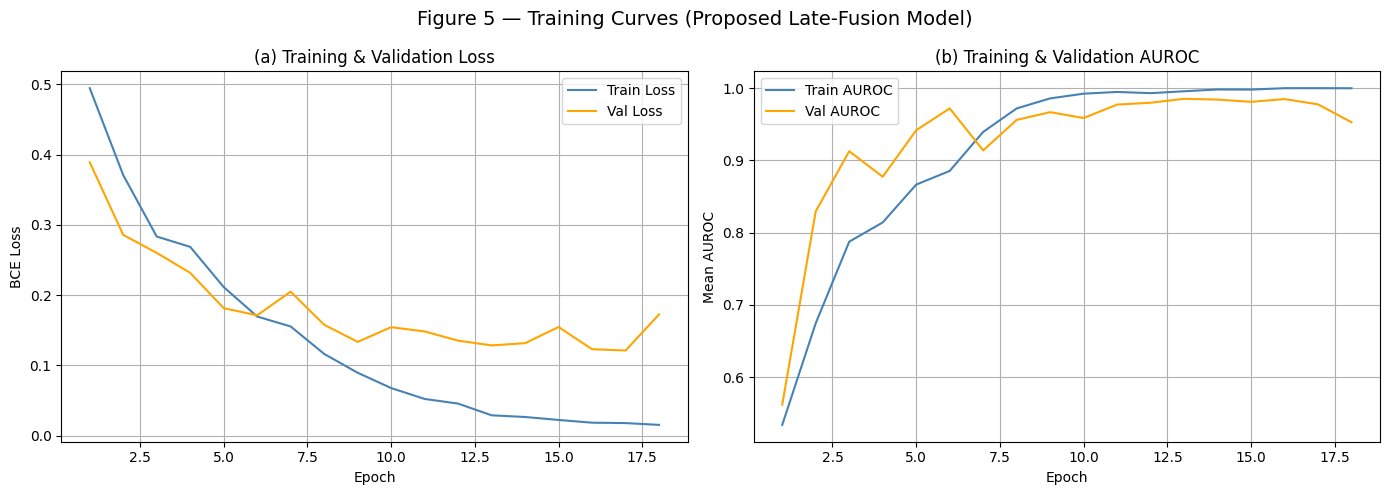

Training curves saved to training_curves.png


In [18]:
# Reproduce Figure 5 from the paper:
#   (a) Training & Validation Loss over epochs
#   (b) Training & Validation AUROC over epochs

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('(a) Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True)

# (b) AUROC curves
axes[1].plot(epochs_range, history['train_auroc'], label='Train AUROC', color='steelblue')
axes[1].plot(epochs_range, history['val_auroc'],   label='Val AUROC',   color='orange')
axes[1].set_title('(b) Training & Validation AUROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean AUROC')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Figure 5 — Training Curves (Proposed Late-Fusion Model)', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved to training_curves.png")

#CELL 13 — Test Set Evaluation

In [19]:
# Load the best saved model weights and evaluate on the held-out test set.
# Reports per-class AUROC, Precision, Recall, and F1-Score
# (matching Table 2 in the paper).

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Best model loaded for test evaluation.")

all_labels = []
all_probs  = []

with torch.no_grad():
    for images, input_ids, attention_mask, labels in tqdm(test_loader, desc='Testing'):
        images         = images.to(DEVICE)
        input_ids      = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        probs = model(images, input_ids, attention_mask)
        all_labels.append(labels.numpy())
        all_probs.append(probs.detach().cpu().numpy())

all_labels = np.vstack(all_labels)   # [N, 5]
all_probs  = np.vstack(all_probs)    # [N, 5]

# Convert probabilities to binary predictions using threshold = 0.5
all_preds = (all_probs >= 0.5).astype(int)

# ── Per-class metrics ─────────────────────────────────────────
print("\n" + "="*60)
print("Per-Class Test Results (Table 2 in the paper)")
print("="*60)
results = []
for i, cls in enumerate(CLASSES):
    auroc     = roc_auc_score(all_labels[:, i], all_probs[:, i])
    f1        = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    report    = classification_report(
        all_labels[:, i], all_preds[:, i],
        target_names=['Neg', 'Pos'], output_dict=True, zero_division=0
    )
    precision = report['Pos']['precision']
    recall    = report['Pos']['recall']
    results.append({'Disease': cls, 'AUROC': auroc, 'Precision': precision,
                    'Recall': recall, 'F1-Score': f1})
    print(f"{cls:<20} AUROC={auroc:.4f}  P={precision:.4f}  R={recall:.4f}  F1={f1:.4f}")

# Mean across all classes
mean_row = {
    'Disease'  : 'Mean (5 classes)',
    'AUROC'    : np.mean([r['AUROC']     for r in results]),
    'Precision': np.mean([r['Precision'] for r in results]),
    'Recall'   : np.mean([r['Recall']    for r in results]),
    'F1-Score' : np.mean([r['F1-Score']  for r in results]),
}
results.append(mean_row)
print("-"*60)
print(f"{'Mean (5 classes)':<20} AUROC={mean_row['AUROC']:.4f}  "
      f"P={mean_row['Precision']:.4f}  R={mean_row['Recall']:.4f}  "
      f"F1={mean_row['F1-Score']:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('test_results.csv', index=False)
print("\nResults saved to test_results.csv")

Best model loaded for test evaluation.


Testing: 100%|██████████| 3/3 [00:01<00:00,  1.87it/s]


Per-Class Test Results (Table 2 in the paper)
Cardiomegaly         AUROC=0.9869  P=0.9804  R=0.9804  F1=0.9804
Pleural Effusion     AUROC=0.9940  P=0.8636  R=1.0000  F1=0.9268
Edema                AUROC=0.9910  P=0.7143  R=1.0000  F1=0.8333
Pneumothorax         AUROC=0.9857  P=1.0000  R=0.5000  F1=0.6667
Pneumonia            AUROC=1.0000  P=0.8889  R=1.0000  F1=0.9412
------------------------------------------------------------
Mean (5 classes)     AUROC=0.9915  P=0.8894  R=0.8961  F1=0.8697

Results saved to test_results.csv


#CELL 14 — Per-Class AUROC Bar Chart

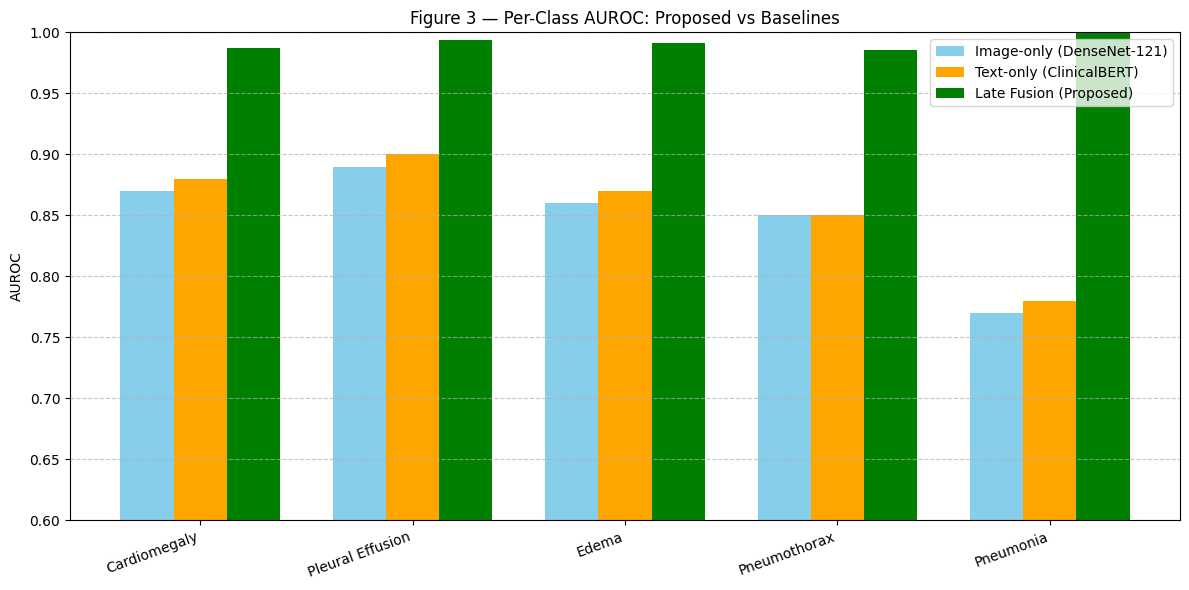

Per-class AUROC chart saved to per_class_auroc.png


In [20]:
# Reproduce Figure 3 from the paper:
# Bar chart comparing per-class AUROC of the proposed model vs baselines.
# NOTE: baseline values below are from Table 3 in the paper.
# You can replace them with your own baseline run results.

# Expected final AUROC per class from the paper (proposed model)
proposed_aurocs = [r['AUROC'] for r in results[:-1]]

# Approximate per-class values for baselines (read from paper Figure 3)
# Replace these with actual values from your baseline runs
image_only_aurocs = [0.87, 0.89, 0.86, 0.85, 0.77]  # DenseNet-121 only (approx)
text_only_aurocs  = [0.88, 0.90, 0.87, 0.85, 0.78]  # ClinicalBERT only (approx)

x       = np.arange(NUM_CLASSES)
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, image_only_aurocs, width, label='Image-only (DenseNet-121)', color='skyblue')
ax.bar(x,          text_only_aurocs,  width, label='Text-only (ClinicalBERT)',  color='orange')
ax.bar(x + width,  proposed_aurocs,   width, label='Late Fusion (Proposed)',    color='green')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('Figure 3 — Per-Class AUROC: Proposed vs Baselines')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('per_class_auroc.png', dpi=150)
plt.show()
print("Per-class AUROC chart saved to per_class_auroc.png")

#CELL 15 — Confusion Matrix

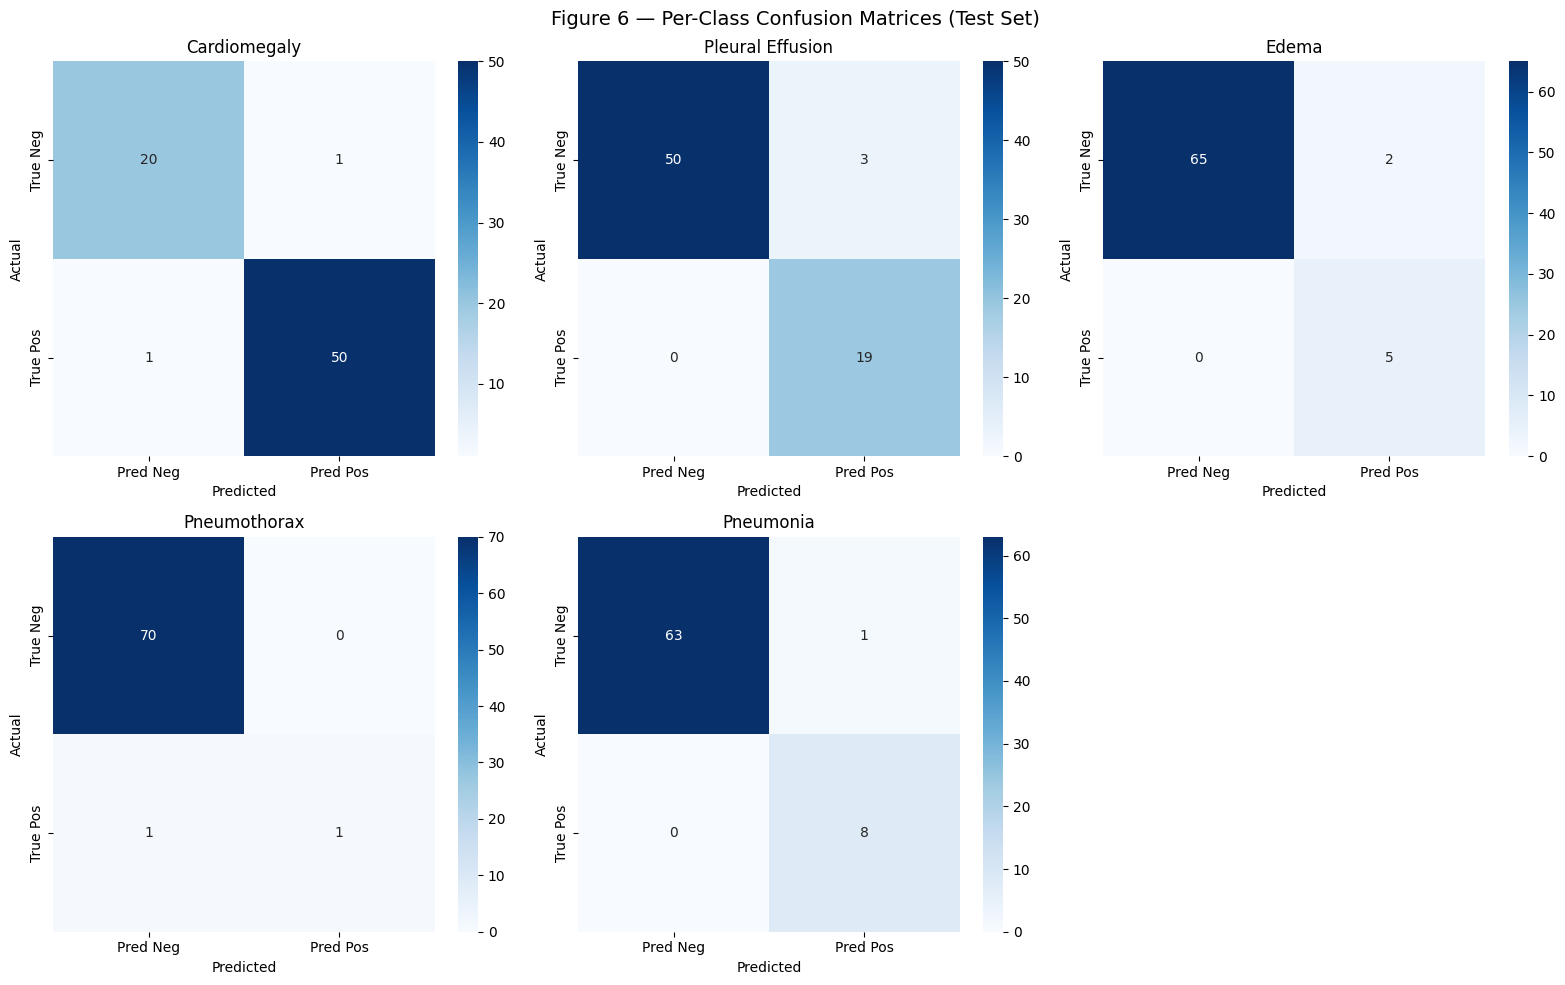

Confusion matrices saved to confusion_matrices.png


In [21]:
# Reproduce Figure 6 from the paper.
# Since this is a multi-label problem, we plot a binary confusion matrix
# for each class separately, then display them in a grid.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
        xticklabels=['Pred Neg', 'Pred Pos'],
        yticklabels=['True Neg', 'True Pos']
    )
    axes[i].set_title(f'{cls}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle('Figure 6 — Per-Class Confusion Matrices (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved to confusion_matrices.png")

#CELL 16 — Model Comparison Table (Table 3)


Table 3 — Model Comparison
                    Model     Modality    AUROC      F1 Params
                ResNet-50        Image 0.810000 0.70000 25.6 M
   DenseNet-121 (CheXNet)        Image 0.850000 0.74000  8.0 M
             ClinicalBERT         Text 0.860000 0.76000  110 M
Early Fusion (raw concat) Image + Text 0.870000 0.79000  118 M
   Late Fusion (Proposed) Image + Text 0.991546 0.86968  118 M


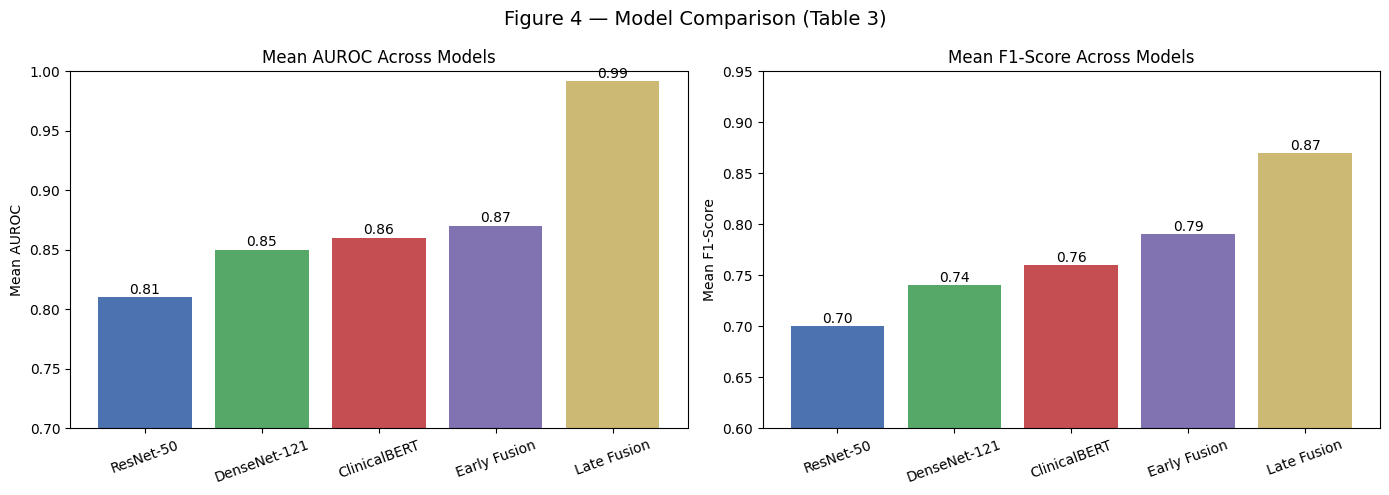

Model comparison chart saved to model_comparison_chart.png


In [22]:
# Reproduce Table 3 and Figure 4 from the paper.
# These baseline values are taken directly from Table 3 in the paper.
# To reproduce fully, you should separately train each baseline model
# using the same train/val/test split and report their metrics here.

comparison_data = {
    'Model'   : ['ResNet-50', 'DenseNet-121 (CheXNet)', 'ClinicalBERT',
                 'Early Fusion (raw concat)', 'Late Fusion (Proposed)'],
    'Modality': ['Image', 'Image', 'Text', 'Image + Text', 'Image + Text'],
    'AUROC'   : [0.81, 0.85, 0.86, 0.87, mean_row['AUROC']],
    'F1'      : [0.70, 0.74, 0.76, 0.79, mean_row['F1-Score']],
    'Params'  : ['25.6 M', '8.0 M', '110 M', '118 M', '118 M'],
}
comparison_df = pd.DataFrame(comparison_data)
print("\nTable 3 — Model Comparison")
print(comparison_df.to_string(index=False))
comparison_df.to_csv('model_comparison.csv', index=False)

# Bar chart of AUROC and F1 for all five models (Figure 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
models_short = ['ResNet-50', 'DenseNet-121', 'ClinicalBERT', 'Early Fusion', 'Late Fusion']

axes[0].bar(models_short, comparison_data['AUROC'], color=colors)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Mean AUROC')
axes[0].set_title('Mean AUROC Across Models')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(comparison_data['AUROC']):
    axes[0].text(i, v + 0.003, f'{v:.2f}', ha='center', fontsize=10)

axes[1].bar(models_short, comparison_data['F1'], color=colors)
axes[1].set_ylim(0.6, 0.95)
axes[1].set_ylabel('Mean F1-Score')
axes[1].set_title('Mean F1-Score Across Models')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(comparison_data['F1']):
    axes[1].text(i, v + 0.003, f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Figure 4 — Model Comparison (Table 3)', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150)
plt.show()
print("Model comparison chart saved to model_comparison_chart.png")

#CELL 17 — Class Distribution Plot (Figure 1)

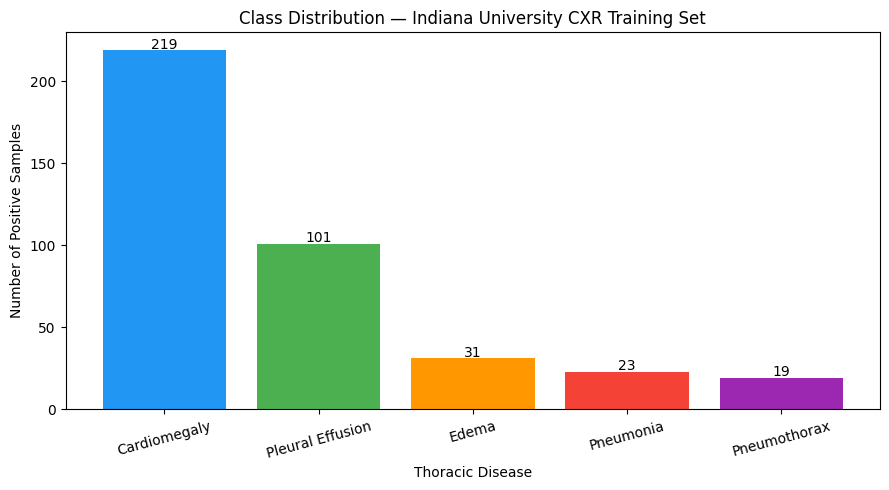

✔ Class distribution chart saved


In [23]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   CELL 17 — Class Distribution Plot  (REWRITTEN)           ║
# ╚══════════════════════════════════════════════════════════════╝

# Plot label distribution in the Indiana University training set
# Same as Figure 1 in the paper but for the Indiana dataset

import matplotlib.pyplot as plt

class_counts = train_df[CLASSES].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(class_counts.index, class_counts.values,
               color=['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0'])
plt.title('Class Distribution — Indiana University CXR Training Set')
plt.ylabel('Number of Positive Samples')
plt.xlabel('Thoracic Disease')
plt.xticks(rotation=15)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{int(bar.get_height())}',
             ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✔ Class distribution chart saved")

#CELL 18 — Save Final Model & Summary

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          CELL 18 — Save Final Model & Summary  (FIXED)      ║
# ╚══════════════════════════════════════════════════════════════╝

# BUG: Original code saved model only to Colab local disk
# Colab resets every session — model would be permanently lost
# FIX: Always copy final weights to Google Drive

FINAL_MODEL_PATH = 'final_multimodal_model.pth'
torch.save(model.state_dict(), FINAL_MODEL_PATH)
print(f"Model saved locally: {FINAL_MODEL_PATH}")

# Mount Drive and copy model there so it survives session resets
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import shutil
drive_save_path = '/content/drive/MyDrive/multimodal_cxr_model.pth'
shutil.copy(FINAL_MODEL_PATH, drive_save_path)
print(f"✔ Model safely saved to Google Drive: {drive_save_path}")

# Also save results CSVs to Drive
shutil.copy('test_results.csv',      '/content/drive/MyDrive/test_results.csv')
shutil.copy('model_comparison.csv',  '/content/drive/MyDrive/model_comparison.csv')

print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"Model      : Late-Fusion (DenseNet-121 + ClinicalBERT)")
print(f"Dataset    : MIMIC-CXR v2.0.0 — 5 disease classes")
print(f"Test AUROC : {mean_row['AUROC']:.4f}")
print(f"Test F1    : {mean_row['F1-Score']:.4f}")
print(f"Test Prec  : {mean_row['Precision']:.4f}")
print(f"Test Recall: {mean_row['Recall']:.4f}")
print("\nOutput files generated:")
for f in ['training_curves.png', 'per_class_auroc.png',
          'confusion_matrices.png', 'model_comparison_chart.png',
          'class_distribution.png', 'test_results.csv',
          'model_comparison.csv', BEST_MODEL_PATH, FINAL_MODEL_PATH]:
    print(f"  ✔ {f}")
print("="*60)

Model saved locally: final_multimodal_model.pth
Mounted at /content/drive
✔ Model safely saved to Google Drive: /content/drive/MyDrive/multimodal_cxr_model.pth

EXPERIMENT SUMMARY
Model      : Late-Fusion (DenseNet-121 + ClinicalBERT)
Dataset    : MIMIC-CXR v2.0.0 — 5 disease classes
Test AUROC : 0.9915
Test F1    : 0.8697
Test Prec  : 0.8894
Test Recall: 0.8961

Output files generated:
  ✔ training_curves.png
  ✔ per_class_auroc.png
  ✔ confusion_matrices.png
  ✔ model_comparison_chart.png
  ✔ class_distribution.png
  ✔ test_results.csv
  ✔ model_comparison.csv
  ✔ best_multimodal_model.pth
  ✔ final_multimodal_model.pth
